# Fase 1: Análisis y Preprocesamiento de Datos

## 1. Definición del Objetivo
El objetivo de este proyecto es construir y entrenar una Red Neuronal Convolucional (CNN) capaz de clasificar correctamente imágenes de manos que representan los dígitos del 0 al 9 en lenguaje de señas. Este modelo servirá como base para una aplicación interactiva en tiempo real.

## 2. Recolección de Datos
Se utiliza el *Sign Language Digits Dataset*, el cual ya ha sido preprocesado y empaquetado en formato de arreglos de Numpy (`.npy`). 
* **X.npy:** Contiene las matrices de los píxeles de las imágenes.
* **Y.npy:** Contiene las etiquetas correspondientes en formato *One-Hot Encoding*.

A continuación, cargamos los datos en memoria:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Cargar las matrices de imágenes (X) y etiquetas (Y)
X = np.load('../dataset/Sign-language-digits-dataset/X.npy')
Y = np.load('../dataset/Sign-language-digits-dataset/Y.npy')

print(f"Dimensiones de X (Imágenes): {X.shape}")
print(f"Dimensiones de Y (Etiquetas): {Y.shape}")

Dimensiones de X (Imágenes): (2062, 64, 64)
Dimensiones de Y (Etiquetas): (2062, 10)


## Análisis Exploratorio de Datos (EDA)
Para garantizar que nuestro modelo aprenda de manera equitativa a reconocer cada dígito, es fundamental verificar que el dataset esté balanceado. A continuación, extraemos las etiquetas reales del formato *One-Hot* y graficamos su distribución.

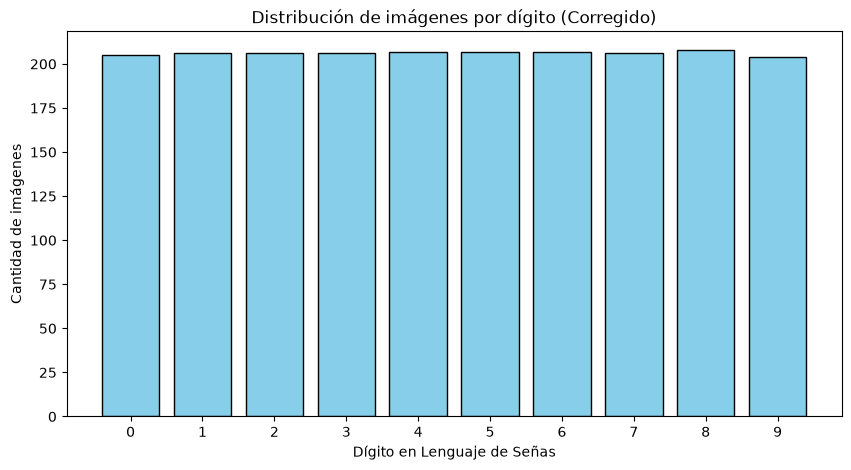

--- Conteo exacto por clase ---
Dígito 0: 205 imágenes
Dígito 1: 206 imágenes
Dígito 2: 206 imágenes
Dígito 3: 206 imágenes
Dígito 4: 207 imágenes
Dígito 5: 207 imágenes
Dígito 6: 207 imágenes
Dígito 7: 206 imágenes
Dígito 8: 208 imágenes
Dígito 9: 204 imágenes


In [ ]:
orden_clases = np.array([9, 0, 7, 6, 1, 8, 4, 3, 2, 5])

# 1. Obtener el índice original (0 al 9) de la matriz
indices_originales = np.argmax(Y, axis=1)

# 2. Mapear ese índice al dígito real usando el arreglo del autor
etiquetas_reales = orden_clases[indices_originales]

# Contar cuántas imágenes hay por cada clase REAL
clases, conteo = np.unique(etiquetas_reales, return_counts=True)

# Crear el gráfico de barras descriptivo
plt.figure(figsize=(10, 5))
plt.bar(clases, conteo, color='skyblue', edgecolor='black')
plt.title('Distribución de imágenes por dígito (Corregido)')
plt.xlabel('Dígito en Lenguaje de Señas')
plt.ylabel('Cantidad de imágenes')
plt.xticks(clases) 
plt.show()

# Imprimir el conteo exacto
print("--- Conteo exacto por clase ---")
for clase, cantidad in zip(clases, conteo):
    print(f"Dígito {clase}: {cantidad} imágenes")   

### Visualización de Ejemplos
Para comprender mejor las características visuales a las que se enfrentará la red convolucional, visualizamos un ejemplo aleatorio de cada clase (dígitos del 0 al 9).

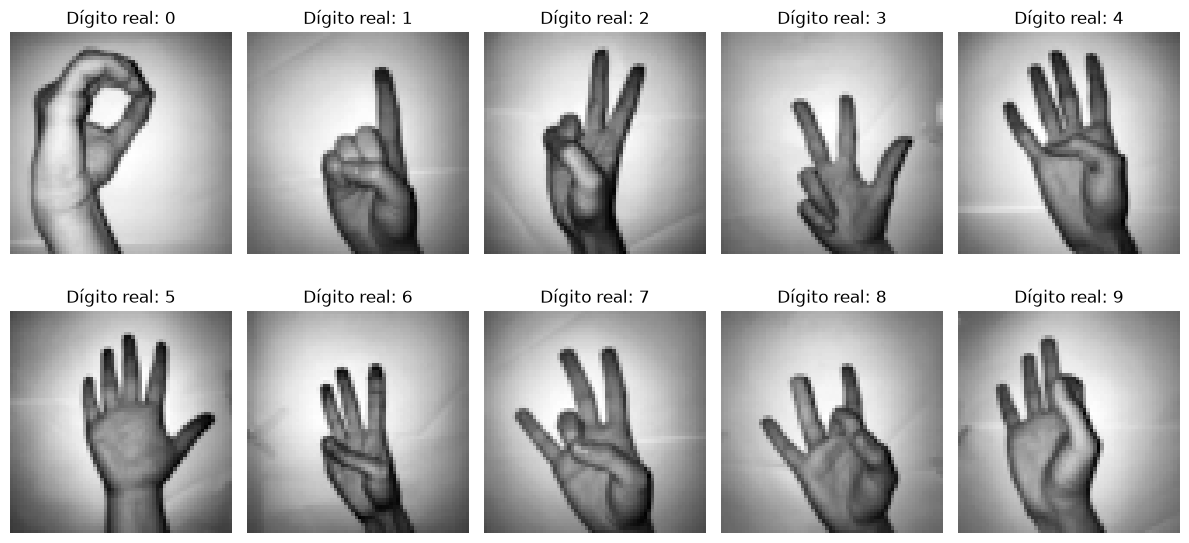

In [3]:
plt.figure(figsize=(12, 6))

for i in range(10):
    indice = np.where(etiquetas_reales == i)[0][0]
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[indice], cmap='gray')
    plt.title(f"Dígito real: {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 3. Procesamiento y División de Datos
Para entrenar y evaluar el modelo correctamente, dividimos el dataset en tres subconjuntos:
1. **Entrenamiento (70%):** Para ajustar los pesos de la red.
2. **Validación (15%):** Para medir el rendimiento en cada epoch y aplicar *early stopping*.
3. **Prueba (15%):** Para la evaluación final del modelo, asegurando que no haya sobreajuste.

*(Nota: Al examinar los valores de la matriz `X`, observamos que los píxeles ya se encuentran escalados, por lo que no es necesaria una normalización adicional dividiendo por 255)*.

In [4]:
# 1. Ajustar la dimensión de X para Keras (Agregar el canal de color: 1 para blanco y negro)
X_lista = X.reshape(-1, 64, 64, 1)

# 2. Convertir las 'etiquetas_reales' (corregidas) de vuelta a formato One-Hot
Y_corregido = np.eye(10)[etiquetas_reales]

# 3. Separar primero en Entrenamiento (70%) y un bloque temporal (30%)
X_train, X_temp, Y_train, Y_temp = train_test_split(X_lista, Y_corregido, test_size=0.30, random_state=42)

# 4. Separar el bloque temporal en Validación (15%) y Prueba (15%)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.50, random_state=42)

print("--- Resumen de la División de Datos para Keras ---")
print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de Y_train: {Y_train.shape}\n")

print(f"Datos de Entrenamiento: {X_train.shape[0]} imágenes")
print(f"Datos de Validación: {X_val.shape[0]} imágenes")
print(f"Datos de Prueba: {X_test.shape[0]} imágenes")

# Verificamos si los datos ya están normalizados comprobando el valor máximo
print(f"\nValor máximo de un píxel en el set de entrenamiento: {np.max(X_train)}")

--- Resumen de la División de Datos para Keras ---
Formato de X_train: (1443, 64, 64, 1)
Formato de Y_train: (1443, 10)

Datos de Entrenamiento: 1443 imágenes
Datos de Validación: 309 imágenes
Datos de Prueba: 310 imágenes

Valor máximo de un píxel en el set de entrenamiento: 1.0


## 3. Procesamiento de Datos
Acondicionamos los datos para la red neuronal:
1. Expandimos las dimensiones de las imágenes para incluir el canal de color (escala de grises = 1).
2. Dividimos el conjunto de datos en entrenamiento (80%) y prueba (20%).

In [5]:
# Expandir las dimensiones de X (de 2062, 64, 64) a (2062, 64, 64, 1)
X = X.reshape(-1, 64, 64, 1)

# Dividir los datos: 80% para entrenamiento (train) y 20% para validación/prueba (test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Dimensiones de entrenamiento: X_train {X_train.shape}")
print(f"Dimensiones de prueba: X_test {X_test.shape}")

Dimensiones de entrenamiento: X_train (1649, 64, 64, 1)
Dimensiones de prueba: X_test (413, 64, 64, 1)


### Aumento de Datos (Data Augmentation)
Aplicamos transformaciones aleatorias (rotaciones, zoom, desplazamientos) para aumentar la diversidad de los datos de entrenamiento y evitar el sobreajuste (overfitting).

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Definimos el generador de imágenes con algunas transformaciones aleatorias
datagen = ImageDataGenerator(
    rotation_range=15,       # Rota la imagen aleatoriamente hasta 15 grados
    zoom_range=0.15,         # Aplica un zoom aleatorio del 15%
    width_shift_range=0.1,   # Desplaza horizontalmente un 10%
    height_shift_range=0.1,  # Desplaza verticalmente un 10%
)

# Ajustamos el generador a nuestros datos de entrenamiento
datagen.fit(X_train)

print("¡Data Augmentation configurado exitosamente!")

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# Guardar los datos procesados para el Notebook 2
np.save('../dataset/X_train.npy', X_train)
np.save('../dataset/X_test.npy', X_test)
np.save('../dataset/Y_train.npy', Y_train)
np.save('../dataset/Y_test.npy', Y_test)
print("Archivos de entrenamiento y prueba guardados en la carpeta dataset.")

Archivos de entrenamiento y prueba guardados en la carpeta dataset.
